In [ ]:
import numpy as np
import pandas as pd
import plotnine as p9
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time 
from joblib import Parallel, delayed
from bs4 import BeautifulSoup

import json
from pathlib import Path

import requests
from datetime import datetime
import pymc as pm
from datetime import datetime, timezone, timedelta

import xgboost as xgb
import lightgbm as lgb
import statsmodels.api as sm
from sklearn.metrics import (
    mean_absolute_percentage_error, mean_squared_error, r2_score,
    precision_recall_curve, average_precision_score,
    classification_report, confusion_matrix
)
from sklearn.model_selection import KFold

ModuleNotFoundError: No module named 'beach_status'

> Hazardous algal blooms (HABs) are primarily caused by: 
1. excessive nutrient enrichment (nitrogen and phosphorus)
2. warm temperatures
3. abundant sunlight, 
4. calm, slow-moving water conditions

### Get data
* beach closure history
* weather
* usgs_champlain_climate 
* usgs_winooski_discharge

In [66]:
lat = 44.4759
lon = -73.2121
start = datetime(2016, 6, 1)
end = datetime(2025, 10, 1)

model_type = "lgb"  # options: "xgb", "lgb"

In [ ]:
weather_parquet_path = '../data/btv_weather_data_2016_2025.parquet'

if os.path.exists(weather_parquet_path):
    print(f"Loading weather data from {weather_parquet_path}")
    weather_df = pd.read_parquet(weather_parquet_path)
else:
    print("Parquet file not found, fetching from Open-Meteo API...")
    response = requests.get(
        'https://archive-api.open-meteo.com/v1/archive',
        params={
            'latitude': lat,
            'longitude': lon,
            'start_date': '2026-06-30',
            'end_date': '2026-07-04',
            'hourly': 'temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,wind_direction_10m,cloud_cover,shortwave_radiation,direct_normal_irradiance,diffuse_radiation,uv_index',
            'temperature_unit': 'fahrenheit',
            'wind_speed_unit': 'mph',
            'precipitation_unit': 'inch'
        }
    )
    response.raise_for_status()
    weather_data = response.json()
    print(f"Fetched {len(weather_data['hourly']['time'])} hourly records")

    hourly = weather_data['hourly']

    weather_df = (
        pd.DataFrame({
            "datetime":              hourly["time"],
            "datetime_local":        pd.to_datetime(hourly["time"]).tz_localize('GMT').tz_convert('America/New_York'),
            "temp_f":                hourly["temperature_2m"],
            "relative_humidity_pct": hourly["relative_humidity_2m"],
            "precipitation_in":      hourly["precipitation"],
            "wind_speed_mph":        hourly["wind_speed_10m"],
            "wind_direction_deg":    hourly["wind_direction_10m"],
            "cloud_cover_pct":       hourly["cloud_cover"],
            "shortwave_radiation":   hourly["shortwave_radiation"],   # W/m²
            "direct_normal_irr":     hourly["direct_normal_irradiance"],  # W/m²
            "diffuse_radiation":     hourly["diffuse_radiation"],     # W/m²
            "uv_index":              hourly["uv_index"],
            "fetched_at":            datetime.now(timezone.utc).isoformat(),
            "latitude":              lat,
            "longitude":             lon,
            "utc_offset_seconds":    weather_data.get("utc_offset_seconds", 0),
            "timezone_abbrev":       weather_data.get("timezone_abbreviation", "UTC"),
        })
    )

    weather_df = (
        pd.DataFrame(weather_data['hourly'])
        .assign(
            datetime=lambda df: pd.to_datetime(df['time']).dt.tz_localize('GMT'),
            datetime_local=lambda df: df['datetime'].dt.tz_convert('America/New_York')
        )
    )
    weather_df.to_parquet(weather_parquet_path, index=False)
    print(f"Saved to {weather_parquet_path}")

Loading weather data from data/btv_weather_data_2016_2025.csv


In [116]:
response = requests.get(
    'https://archive-api.open-meteo.com/v1/archive',
    params={
        'latitude': lat,
        'longitude': lon,
        'start_date': '2016-04-30',
        'end_date': '2026-07-03',
        'hourly': 'temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,wind_direction_10m,cloud_cover,shortwave_radiation,direct_normal_irradiance,diffuse_radiation,uv_index',
        'temperature_unit': 'fahrenheit',
        'wind_speed_unit': 'mph',
        'precipitation_unit': 'inch'
    }
)

response.raise_for_status()
weather_data = response.json()
print(f"Fetched {len(weather_data['hourly']['time'])} hourly records")

Fetched 89208 hourly records


### Generate weather feature data

In [ ]:
hourly = weather_data['hourly']

weather_df = (
    pd.DataFrame({
        "datetime":              hourly["time"],
        "datetime_local":        pd.to_datetime(hourly["time"]).tz_localize('GMT').tz_convert('America/New_York'),
        "temp_f":                hourly["temperature_2m"],
        "relative_humidity_pct": hourly["relative_humidity_2m"],
        "precipitation_in":      hourly["precipitation"],
        "wind_speed_mph":        hourly["wind_speed_10m"],
        "wind_direction_deg":    hourly["wind_direction_10m"],
        "cloud_cover_pct":       hourly["cloud_cover"],
        "shortwave_radiation":   hourly["shortwave_radiation"],   # W/m²
        "direct_normal_irr":     hourly["direct_normal_irradiance"],  # W/m²
        "diffuse_radiation":     hourly["diffuse_radiation"],     # W/m²
        "uv_index":              hourly["uv_index"],
        "fetched_at":            (datetime.now(timezone.utc) - timedelta(days=3)).isoformat(),
        "latitude":              lat,
        "longitude":             lon,
        "utc_offset_seconds":    weather_data.get("utc_offset_seconds", 0),
        "timezone_abbrev":       weather_data.get("timezone_abbreviation", "UTC"),
    })
)


In [ ]:
historical_df = (
    weather_df
    .sort_values("fetched_at", ascending=False)
    .drop_duplicates(subset=["datetime", "latitude", "longitude"], keep="first")
    .loc[lambda df: pd.to_datetime(df["datetime"]) > pd.Timestamp.now(tz="UTC").tz_convert(None) - pd.Timedelta(days=3)]
    .sort_values("datetime")
    .reset_index(drop=True)
)

In [144]:
daily_avg = (
    weather_df
    .assign(
        date=lambda df: df.datetime_local.dt.date
        )
    .groupby('date')[['temp_f',
                      'wind_speed_mph',
                      'shortwave_radiation',
                      'direct_normal_irr',
                      'diffuse_radiation',
                      ]]
    .mean()
    .shift(1)  # shift by 1 day
    .rename(columns={'temp_f': 'prior_day_temp', 
                     'wind_speed_mph': 'prior_day_wind_speed',
                     'shortwave_radiation': 'prior_day_shortwave_radiation',
                     'direct_normal_irr': 'prior_day_direct_normal_irradiance',
                     'diffuse_radiation': 'prior_day_diffuse_radiation'})
)

weather_final = (
    weather_df
    .sort_values('datetime_local')
    .assign(
        datetime=lambda df: pd.to_datetime(df["datetime"]),
        date=lambda df: df.datetime_local.dt.date,
        year=lambda df: df.datetime_local.dt.year,
        month=lambda df: df.datetime_local.dt.month,
        day_number=lambda df: df.datetime_local.dt.day_of_year,
        # 1-day rolling mean, sum, and median based on discretion
        rolling_temperature_24h=lambda df: df["temp_f"].transform(
                    lambda x: x.rolling(window=24, min_periods=1).mean()
                    ),
        rolling_precipitation_24h=lambda df: df["precipitation_in"].transform(
                    lambda x: x.rolling(window=24, min_periods=1).sum()
                    ),
        rolling_wind_direction_24h=lambda df: df["wind_direction_deg"].transform(
                    lambda x: x.rolling(window=24, min_periods=1).median()
                    ),
        rolling_wind_speed_24h=lambda df: df["wind_speed_mph"].transform(
            lambda x: x.rolling(window=24, min_periods=1).mean()
            ),
        # 3-day rolling mean, sum, and median based on discretion
        rolling_temperature_72h=lambda df: df["temp_f"].transform(
                    lambda x: x.rolling(window=72, min_periods=1).mean()
                    ),
        rolling_precipitation_72h=lambda df: df["precipitation_in"].transform(
                    lambda x: x.rolling(window=72, min_periods=1).sum()
                    ),
        rolling_wind_direction_72h=lambda df: df["wind_direction_deg"].transform(
                    lambda x: x.rolling(window=72, min_periods=1).median()
                    ),
        rolling_wind_speed_72h=lambda df: df["wind_speed_mph"].transform(
            lambda x: x.rolling(window=72, min_periods=1).mean()
            ),
    )
    .merge(daily_avg, on='date', how='left')
)

### Format dependent hazardous algal bloom (HAB) status
* `hab_beach_closures` - formatted dataframe
* `hab_north_beach_closures` - filtered for North Beach location
* `hab_grouped_closures` - combined closures across all Burlington beaches

> NOTE: I only use the `hab_grouped_closures` dataframe for modeling

In [ ]:
hab_beach_closures = (
    pd.read_parquet('../data/btv_beach_closures.parquet')
    .rename(columns=str.lower)
    .rename(columns={'date': 'date', 'location': 'location', 'alert or closed': 'status', 'number of days': 'duration_days'})
    .assign(
        date=lambda df: pd.to_datetime(df['date'], format='%m/%d/%y'),
        closure_start_date=lambda df: pd.to_datetime(df['date'], format='%m/%d/%y'),
        closure_end_date=lambda df: df['closure_start_date'] + pd.to_timedelta(df['duration_days'].astype(float), unit='D'),
        location_clean=lambda df: df['location'].str.lower().apply(lambda s: s.split()[1] if s.split()[0] == 'the' else s.split()[0]),
        status=lambda df: df['status'].str.lower()
        )
)

hab_north_beach_closures = (
    hab_beach_closures
    .loc[lambda df: df.location_clean == 'north']
    .assign(
        closure_start_datetime=lambda df: df.closure_start_date.dt.tz_localize('America/New_York'),
        closure_end_datetime=lambda df: df.closure_end_date.dt.tz_localize('America/New_York'),
        start_date=lambda df: df.closure_start_datetime.dt.date,
        end_date=lambda df: df.closure_end_datetime.dt.date
    )
)

daily_records = []
for _, row in hab_beach_closures.iterrows():
    dates = pd.date_range(row['closure_start_date'], row['closure_end_date'], freq='D')
    for d in dates:
        daily_records.append({'date': d, 'status': row['status']})

daily_status = pd.DataFrame(daily_records)

status_priority = {'closed': 2, 'alert': 1}

hab_grouped_closures = (
    daily_status
    .assign(priority=lambda df: df['status'].map(status_priority))
    .sort_values('priority', ascending=False)
    .drop_duplicates(subset='date', keep='first')
    .drop(columns='priority')
    .sort_values('date')
    .reset_index(drop=True)
)

### Final DF plus added date + time features

In [146]:
_df = (
    weather_final
    .assign(
        date=lambda df: pd.to_datetime(df['datetime_local'].dt.date)
    )
    .pipe(lambda df: df.merge(hab_grouped_closures, how='left', on='date'))
    .assign(
        status_int = lambda df: np.where(df.status == 'closed', 1, 0),
        year=lambda df: df.datetime_local.dt.year,
        month=lambda df: df.datetime_local.dt.month,
        day_number=lambda df: df.datetime_local.dt.day_of_year,
        status=lambda df: np.where(df.status.isnull(), 'open', df.status),
        status_numeric=lambda df: np.where(
                df.status=='open', 0,              # open = 0
                np.where(df.status=='alert', 0.2,  # alert = 0.2
                1)                                 # closed = 1
            ),                               
        status_classifier=lambda df: np.where(
                df.status=='open', 0, 1) # open = 0,closed = 1
        )
)

In [147]:
features = [
    'temp_f',
    'relative_humidity_pct',
    'precipitation_in',
    'wind_speed_mph', 
    'wind_direction_deg', 
    'cloud_cover_pct',
    'shortwave_radiation', 
    'direct_normal_irr', 
    'diffuse_radiation',

    # 1-day rolling features
    'rolling_temperature_24h',
    'rolling_wind_speed_24h',
    'rolling_wind_direction_24h',
    'rolling_precipitation_24h',

    # 3-day rolling features
    'rolling_temperature_72h',
    'rolling_wind_speed_72h',
    'rolling_wind_direction_72h',
    'rolling_precipitation_72h',

    # prior day features
    'prior_day_temp',
    'prior_day_wind_speed',
    'prior_day_shortwave_radiation',
    'prior_day_direct_normal_irradiance',
    'prior_day_diffuse_radiation',

    # date features
    'month',
    'day_number'
]

select_features = [
    'prior_day_temp',
    'prior_day_wind_speed',
    'prior_day_shortwave_radiation',
    'prior_day_direct_normal_irradiance',
    'prior_day_diffuse_radiation',
]

split_column = 'year'
target_reg = 'status_numeric'
target_class = 'status_classifier'

df_final = (
    _df
    .dropna(subset=features+[target_reg, target_class])
    .loc[lambda df: df.month.isin([6, 7, 8, 9])]
    .loc[lambda df: df.day_number.between(145, 251)]  # Memorial Day to Labor Day (approx.) active testing
    .loc[lambda df: df.year > 2021]
    .loc[lambda df: df.year < 2026]
)

### Write config file

In [ ]:
REG_CONFIG_PATH = Path('../model/config_regression.json')

config = {
    "features": features,
    "target": target_reg,
}

REG_CONFIG_PATH.write_text(json.dumps(config, indent=2))

CLASS_CONFIG_PATH = Path('../model/config_classification.json')

config = {
    "features": features,
    "target": target_class,
}

CLASS_CONFIG_PATH.write_text(json.dumps(config, indent=2))

718

> We remove parts of the year where no monitoring is taking place to avoid training the models on data where we will never see any positives (alerts or closures)

In [148]:
a = 'nope'
if a == 'yep':
    sns.pairplot(
        df_final[select_features + [target_reg]],
        hue=target_reg,
        diag_kind='kde',
        plot_kws={'alpha': 0.25}
    );

## Model

In [165]:
unique_splits = df_final[split_column].unique()
CV_NFOLDS = len(unique_splits)  # leave-one-year-out
kf = KFold(n_splits=CV_NFOLDS, shuffle=True, random_state=18)
X = df_final[features].reset_index(drop=True)
y_reg = df_final[target_reg].reset_index(drop=True)
y_class = df_final[target_class].reset_index(drop=True)

# Aggressively upweight positive class to maximize recall
neg_count = (y_reg == 0).sum()
pos_count = (y_reg == 1).sum()
scale_pos_weight = neg_count / pos_count
recall_boost = 3  # multiplier to further prioritize recall over precision
effective_weight = scale_pos_weight * recall_boost
print(f"scale_pos_weight: {scale_pos_weight:.1f}, effective_weight (x{recall_boost}): {effective_weight:.1f}")

# sample_weight for regressor
sample_weights = np.where(y_reg == 1, effective_weight, 1.0)

predictions_all = np.empty(df_final.shape[0])
predictions_proba = np.empty(df_final.shape[0])  # probability from binary classifier

for train_idx, test_idx in kf.split(unique_splits):
    train_bool = df_final[split_column].isin(unique_splits[train_idx])
    test_bool = df_final[split_column].isin(unique_splits[test_idx])

    train_index = np.where(train_bool.to_numpy())[0]
    test_index = np.where(test_bool.to_numpy())[0]

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train = y_reg.iloc[train_index]
    w_train = sample_weights[train_index]

    # regressor with sample_weight to penalize missed closures
    gbm_model = lgb.LGBMRegressor(scale_pos_weight=effective_weight, verbose=0)
    gbm_model.fit(X_train, y_train, sample_weight=w_train)
    predictions_all[test_index] = np.maximum(gbm_model.predict(X_test), 0)

    # binary classifier with scale_pos_weight for probability output
    gbm_clf = lgb.LGBMClassifier(scale_pos_weight=effective_weight, verbose=0)
    gbm_clf.fit(X_train, y_class.iloc[train_index])
    predictions_proba[test_index] = gbm_clf.predict_proba(X_test)[:, 1]

df_final["gbm_reg_predicted"] = predictions_all
df_final["gbm_class_predicted"] = predictions_proba

# Fit final GBM model on all data
gbm_final_reg = lgb.LGBMRegressor(scale_pos_weight=effective_weight, verbose=0)
gbm_final_reg.fit(X, y_reg, sample_weight=sample_weights)

# Fit final GBM model on all data
gbm_final_class = lgb.LGBMClassifier(scale_pos_weight=effective_weight, verbose=0)
gbm_final_class.fit(X, y_class, sample_weight=sample_weights)

scale_pos_weight: 4.3, effective_weight (x3): 12.9


,scale_pos_weight,np.float64(12.929577464788732)
,verbose,0
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0


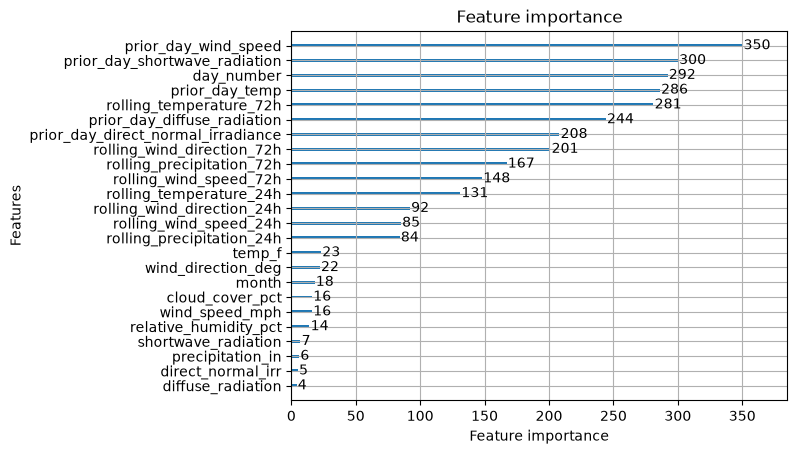

In [166]:
if model_type == "lgb":
    lgb.plot_importance(gbm_final_reg)
else: 
    xgb.plot_importance(gbm_final_reg)

For capturing true positives (actual closures the model correctly identifies), the key metrics are:
* Recall = TP / (TP + FN) — Of all real closures, what fraction did we catch?
* Precision = TP / (TP + FP) — Of what we predicted as closures, how many were real?
* F1 Score — Harmonic mean of precision & recall (balances both)
* Precision-Recall AUC — Better than ROC-AUC for imbalanced data (closures are rare events)

In [160]:
### Regressor threshold sweep - prioritizing recall
print("\n ******** REGRESSOR ******** \n")
print("Threshold sweep (regressor):")
print(f"{'Threshold':<12}{'Recall':<12}{'Precision':<12}{'F1':<12}{'FP':<8}{'TP':<8}")
print("-" * 64)
y_true = df_final[target_reg].astype('int') # effectively removes alerts = 0.2
for t in [0.5, 0.3, 0.2, 0.15, 0.10, 0.05, 0.02]:
    y_pred = (df_final['gbm_reg_predicted'] >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    rec = tp / (tp + fn)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    print(f"{t:<12.2f}{rec:<12.3f}{prec:<12.3f}{f1:<12.3f}{fp:<8}{tp:<8}")

print(f"\nAverage Precision (PR-AUC): {average_precision_score(y_true, df_final['gbm_reg_predicted']):.4f}")

print("\n ******** CLASSIFIER ******** \n")
### Binary classifier with probability threshold tuned for recall
# Sweep thresholds to show precision/recall tradeoff
print("Threshold sweep (classifier):")
print(f"{'Threshold':<12}{'Recall':<12}{'Precision':<12}{'F1':<12}{'FP':<8}{'TP':<8}")
print("-" * 64)
y_true = df_final[target_class]
for t in [0.5, 0.4, 0.3, 0.2, 0.15, 0.10, 0.05]:
    y_pred = (df_final['gbm_class_predicted'] >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn)
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    print(f"{t:<12.2f}{rec:<12.3f}{prec:<12.3f}{f1:<12.3f}{fp:<8}{tp:<8}")

print(f"\nAverage Precision (PR-AUC): {average_precision_score(y_true, df_final['gbm_class_predicted']):.4f}")


 ******** REGRESSOR ******** 

Threshold sweep (regressor):
Threshold   Recall      Precision   F1          FP      TP      
----------------------------------------------------------------
0.50        0.323       0.341       0.332       1061    550     
0.30        0.434       0.332       0.376       1492    740     
0.20        0.493       0.305       0.377       1918    840     
0.15        0.526       0.297       0.380       2125    897     
0.10        0.553       0.284       0.375       2382    943     
0.05        0.606       0.262       0.365       2916    1033    
0.02        0.680       0.255       0.370       3394    1159    

Average Precision (PR-AUC): 0.2938

 ******** CLASSIFIER ******** 

Threshold sweep (classifier):
Threshold   Recall      Precision   F1          FP      TP      
----------------------------------------------------------------
0.50        0.442       0.449       0.446       1211    987     
0.40        0.479       0.447       0.463       1323    1070

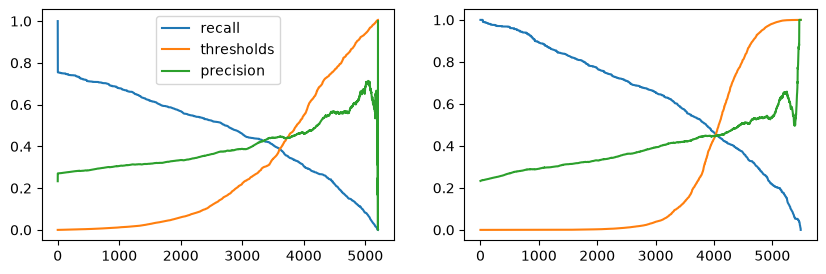

In [161]:
precision, recall, thresholds = precision_recall_curve(y_true, df_final['gbm_reg_predicted'])

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10, 3));
ax1.plot(recall, label='recall')
ax1.plot(thresholds, label='thresholds')
ax1.plot(precision, label='precision')
ax1.legend()

precision, recall, thresholds = precision_recall_curve(y_true, df_final['gbm_class_predicted'])
ax2.plot(recall, label='recall')
ax2.plot(thresholds, label='thresholds')
ax2.plot(precision, label='precision')

## Plotting results

/Users/frederick.hall/work/kuanos/.venv/lib/python3.11/site-packages/plotnine/scales/scale_manual.py:45: PlotnineWarning: The palette of scale_color_manual can return a maximum of 2 values. 3 were requested from it.
/Users/frederick.hall/work/kuanos/.venv/lib/python3.11/site-packages/plotnine/scales/scale_manual.py:45: PlotnineWarning: The palette of scale_color_manual can return a maximum of 2 values. 3 were requested from it.


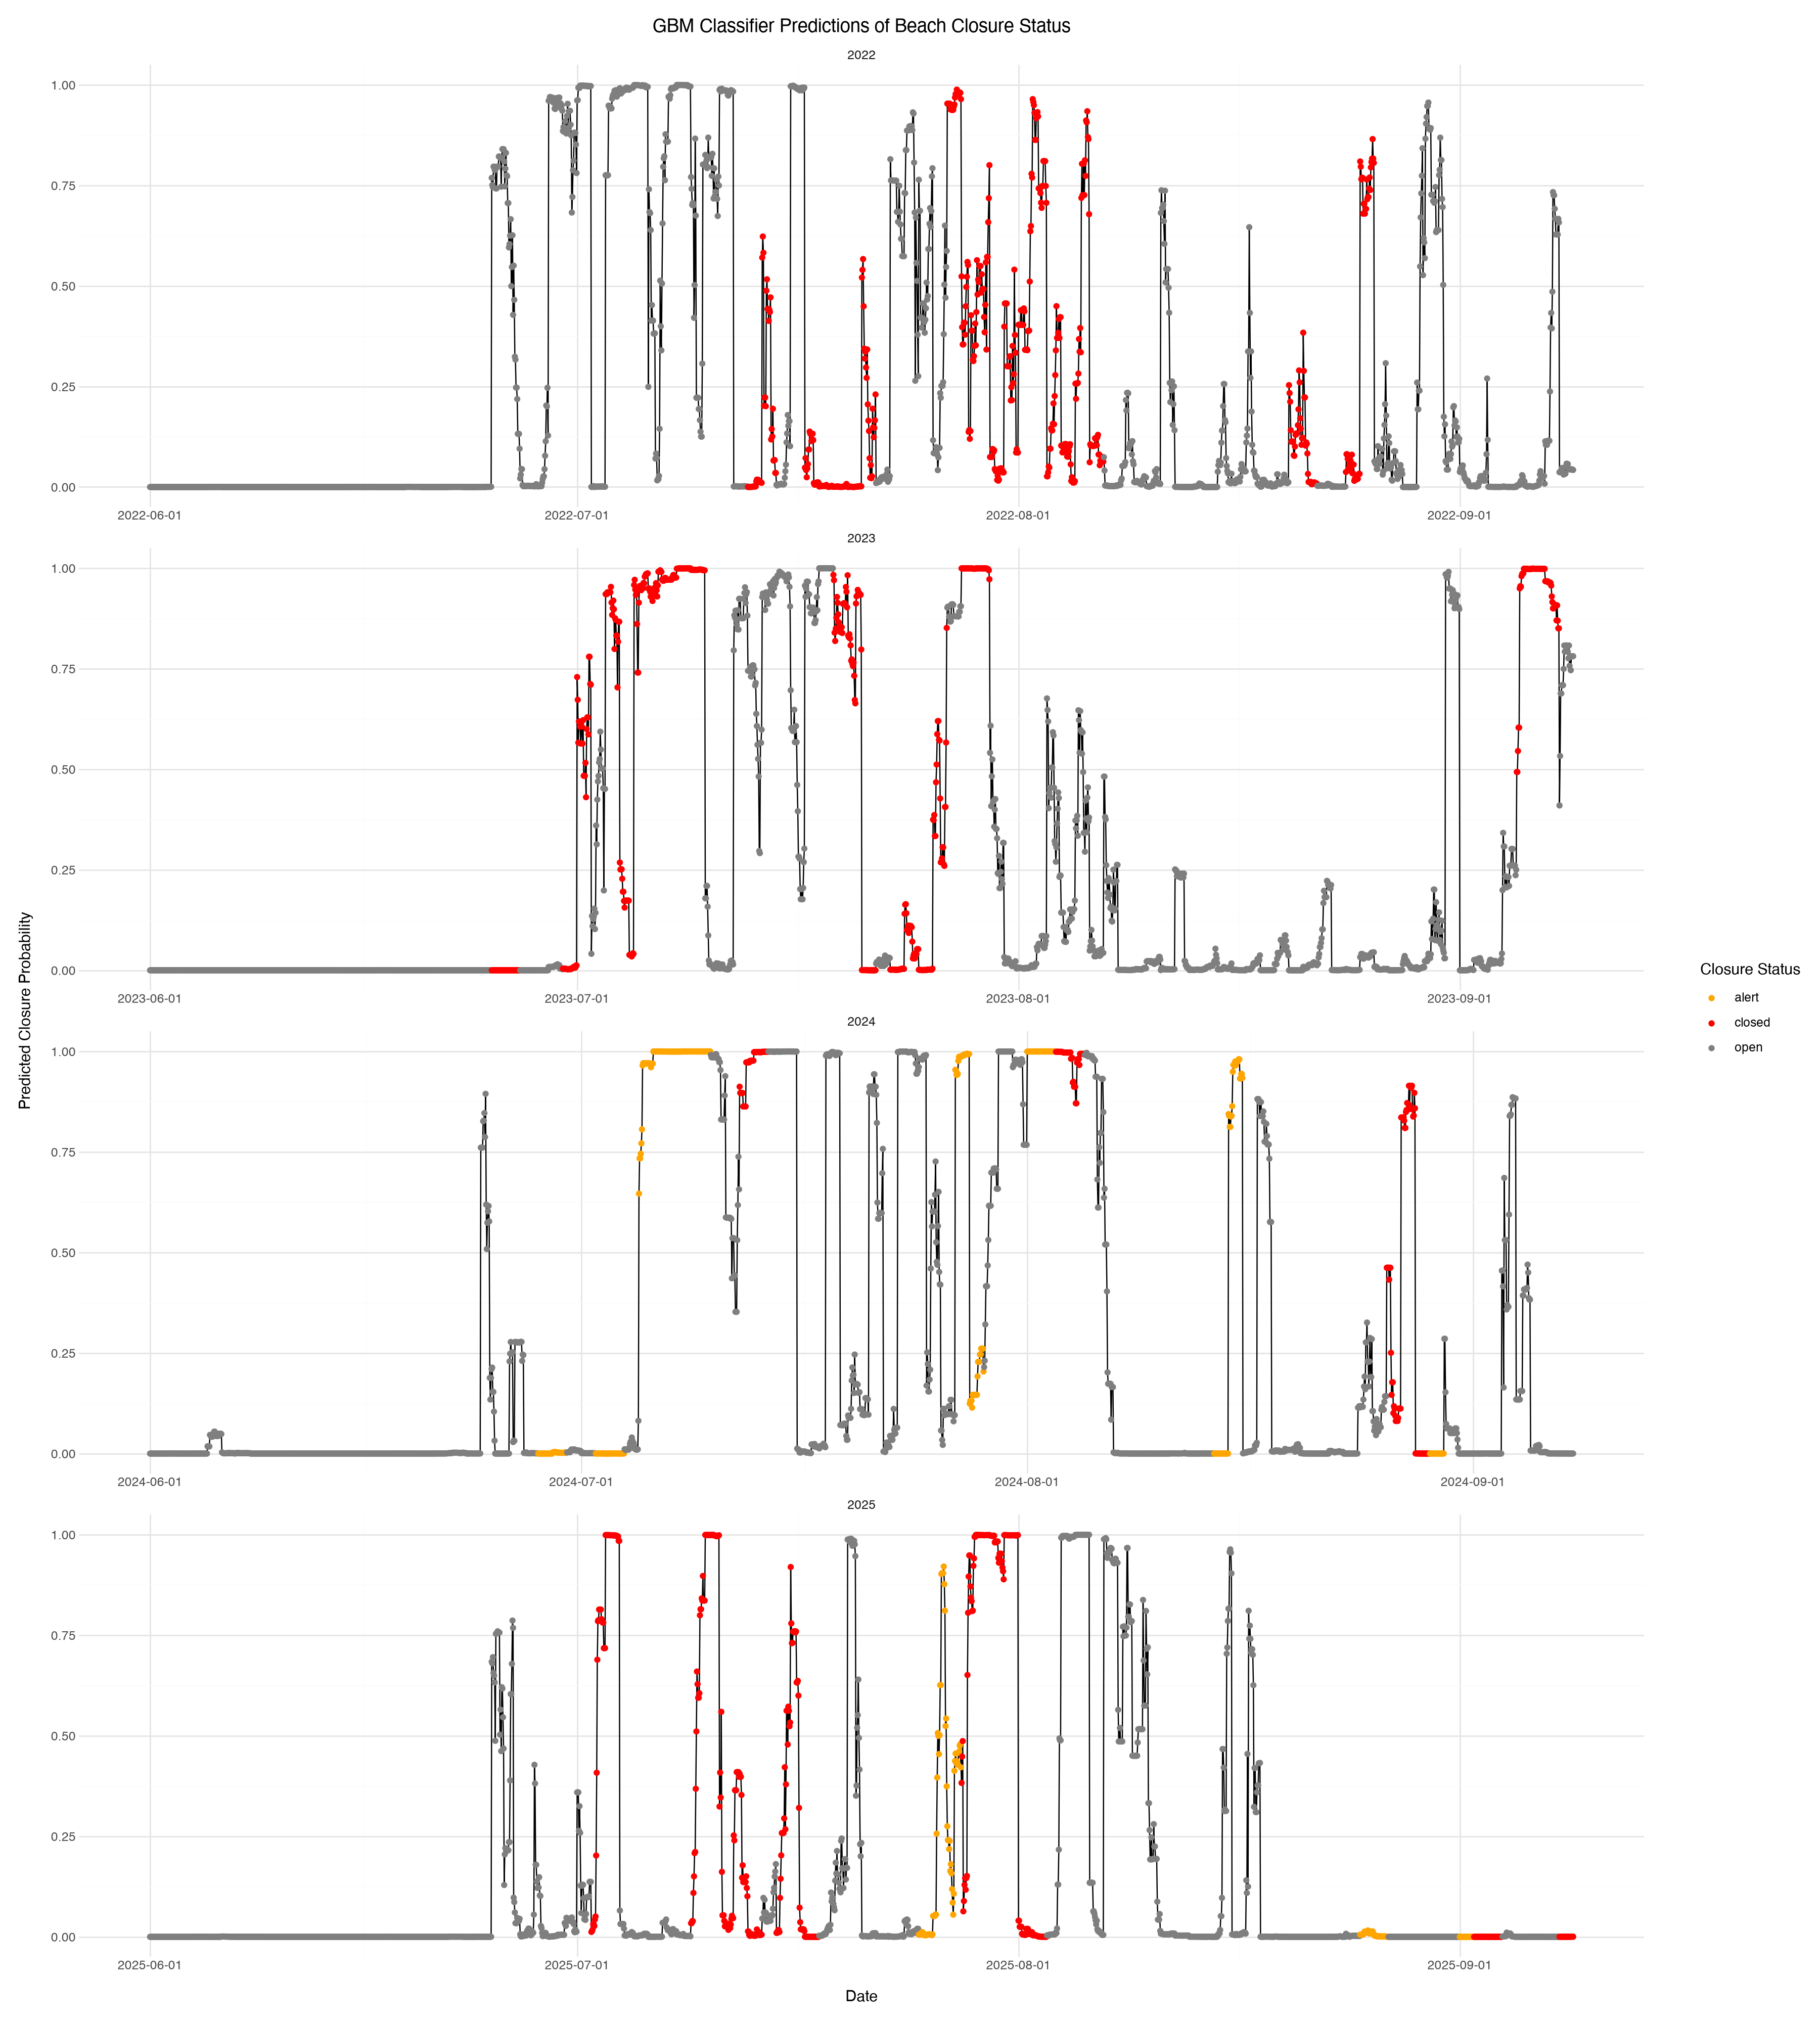

In [162]:
### CLASSIFICATION BY YEAR
p = (
    p9.ggplot(df_final, p9.aes(x='datetime_local', y='gbm_class_predicted')) +
    p9.geom_line() +
    p9.geom_point(p9.aes(color='status')) +
    p9.facet_wrap('year', ncol=1, scales='free_x') +
    p9.labs(title='GBM Classifier Predictions of Beach Closure Status',
        x='Date',
        y='Predicted Closure Probability',
        color='Closure Status'
    ) +
    p9.theme_minimal() +
    p9.theme(figure_size=(18, 20)) +
    p9.scale_color_manual(values={'closed': 'red', 'alert': 'orange'})
)
p

/Users/frederick.hall/work/kuanos/.venv/lib/python3.11/site-packages/plotnine/scales/scale_manual.py:45: PlotnineWarning: The palette of scale_color_manual can return a maximum of 2 values. 3 were requested from it.
/Users/frederick.hall/work/kuanos/.venv/lib/python3.11/site-packages/plotnine/scales/scale_manual.py:45: PlotnineWarning: The palette of scale_color_manual can return a maximum of 2 values. 3 were requested from it.


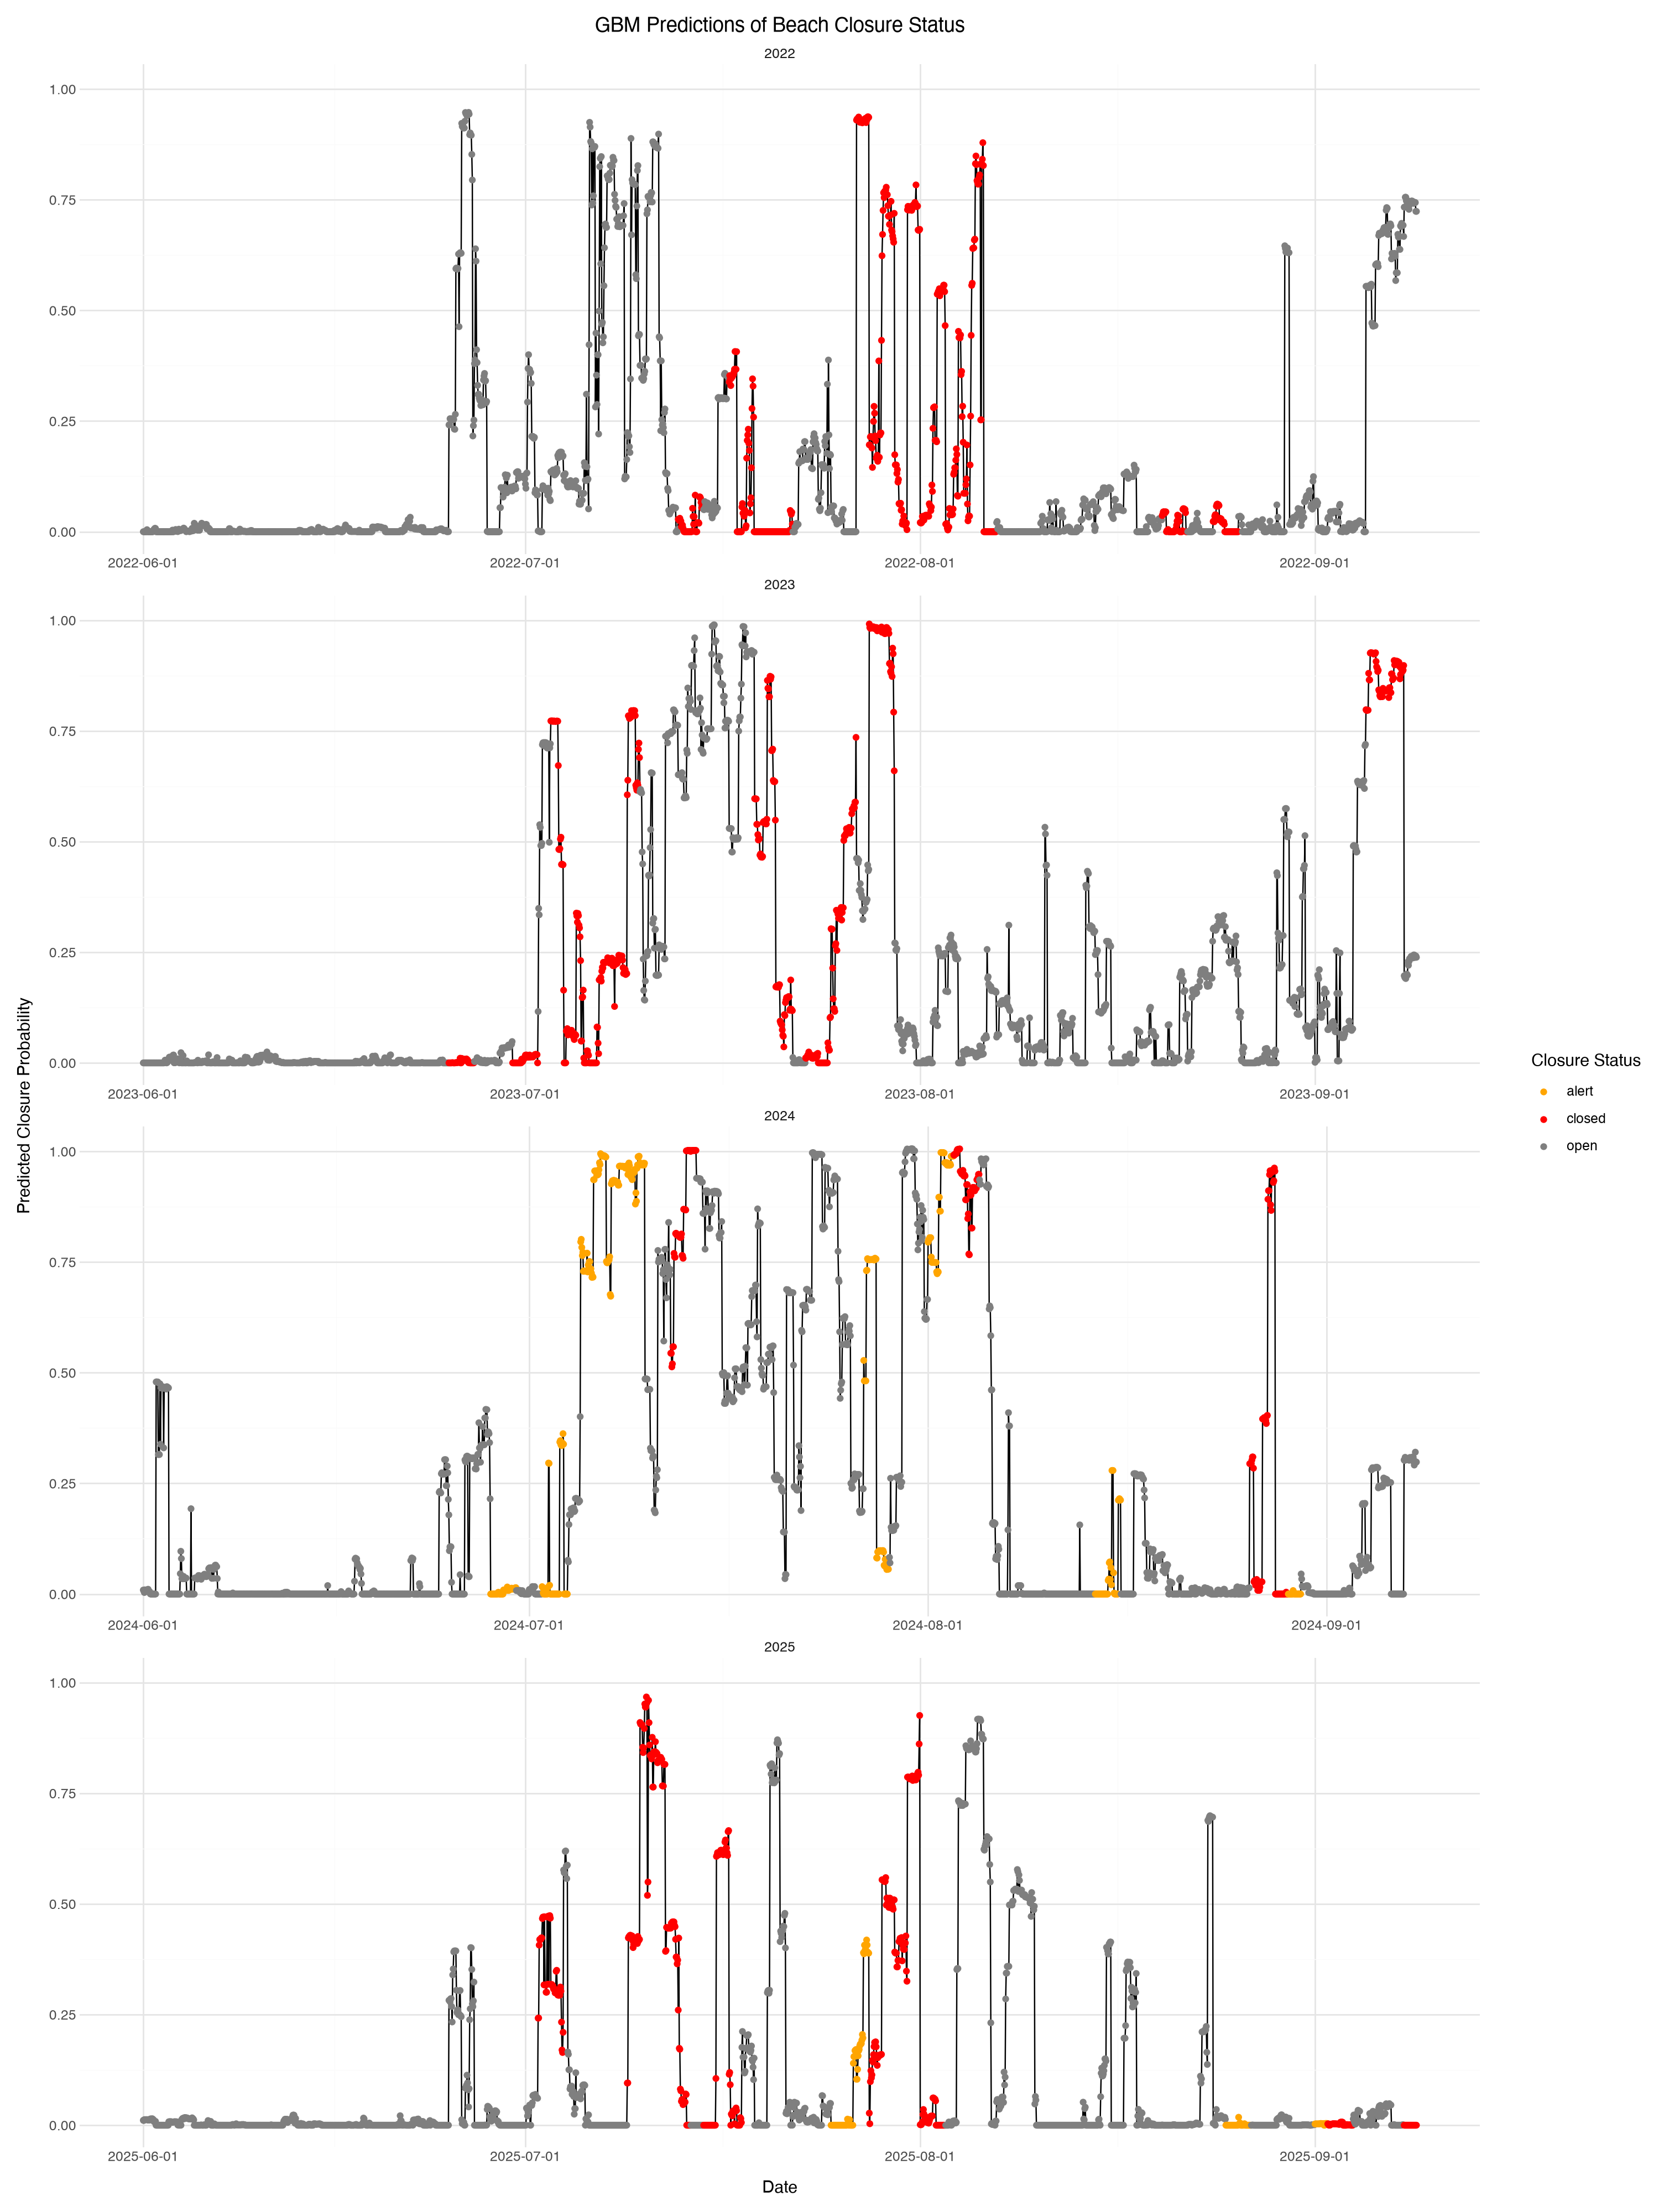

In [163]:
### REGRESSION BY YEAR
p = (
    p9.ggplot(df_final, p9.aes(x='datetime_local', y='gbm_reg_predicted')) +
    p9.geom_line() +
    p9.geom_point(p9.aes(color='status')) +
    p9.facet_wrap('year', ncol=1, scales='free_x') +
    p9.labs(title='GBM Predictions of Beach Closure Status',
        x='Date',
        y='Predicted Closure Probability',
        color='Closure Status'
    ) +
    p9.theme_minimal() +
    p9.theme(figure_size=(15, 20)) +
    p9.scale_color_manual(values={'closed': 'red', 'alert': 'orange'})
)
p

### Good old OLS

In [155]:
X = sm.add_constant(df_final[features])  # adds intercept
model = sm.OLS(df_final[target_reg], X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         status_numeric   R-squared:                       0.192
Model:                            OLS   Adj. R-squared:                  0.190
Method:                 Least Squares   F-statistic:                     94.44
Date:                Fri, 03 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:41:57   Log-Likelihood:                -3303.9
No. Observations:                9576   AIC:                             6658.
Df Residuals:                    9551   BIC:                             6837.
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
======================================================================================================
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
const                                 -1.4031      0.090    -15.559      0.000      -1.580      -1.226
temp_f                                 0.0036      0.001      3.038      0.002       0.001       0.006
relative_humidity_pct                  0.0019      0.000      5.054      0.000       0.001       0.003
precipitation_in                      -0.0567      0.112     -0.508      0.612      -0.276       0.162
wind_speed_mph                        -0.0013      0.001     -0.994      0.320      -0.004       0.001
wind_direction_deg                 -8.322e-05   4.38e-05     -1.900      0.057      -0.000    2.63e-06
cloud_cover_pct                       -0.0007      0.000     -6.746      0.000      -0.001      -0.000
shortwave_radiation                 4.844e-05   4.76e-05      1.018      0.309   -4.48e-05       0.000
direct_normal_irr                   2.404e-06   3.56e-05      0.067      0.946   -6.74e-05    7.22e-05
diffuse_radiation                  -6.768e-05   7.71e-05     -0.878      0.380      -0.000    8.34e-05
rolling_temperature_24h                0.0067      0.002      2.958      0.003       0.002       0.011
rolling_wind_speed_24h                -0.0140      0.002     -6.008      0.000      -0.019      -0.009
rolling_wind_direction_24h            -0.0001    6.6e-05     -2.100      0.036      -0.000   -9.24e-06
rolling_precipitation_24h             -0.0417      0.015     -2.781      0.005      -0.071      -0.012
rolling_temperature_72h                0.0172      0.002      9.166      0.000       0.014       0.021
rolling_wind_speed_72h                 0.0078      0.003      2.596      0.009       0.002       0.014
rolling_wind_direction_72h            -0.0002      0.000     -2.241      0.025      -0.000   -2.87e-05
rolling_precipitation_72h             -0.0347      0.007     -4.642      0.000      -0.049      -0.020
prior_day_temp                        -0.0012      0.002     -0.513      0.608      -0.006       0.003
prior_day_wind_speed                  -0.0193      0.002     -8.760      0.000      -0.024      -0.015
prior_day_shortwave_radiation         -0.0002      0.000     -0.611      0.541      -0.001       0.001
prior_day_direct_normal_irradiance    -0.0002      0.000     -0.679      0.497      -0.001       0.000
prior_day_diffuse_radiation            0.0002      0.000      0.327      0.743      -0.001       0.001
month                                  0.0158      0.012      1.287      0.198      -0.008       0.040
day_number                            -0.0003      0.000     -0.737      0.461      -0.001       0.001
==============================================================================
Omnibus:                     1347.615   Durbin-Watson:                   0.039
Prob(Omnibus):                  0.000   J

# Write model to file

In [168]:
gbm_final_reg.booster_.save_model(str('../model/gbm_regression_model.txt'))
gbm_final_class.booster_.save_model(str('../model/gbm_classification_model.txt'))

# Test beach status

In [19]:
import asyncio
import json
import re
import pandas as pd
from datetime import datetime, timezone
from pathlib import Path

import sys
sys.path.insert(0, '..')

from src.beach_status import scrape_beach_statuses

In [42]:
PATH = Path('../data/beach_status.parquet')
pd.read_parquet(PATH).head()

,beach_name,status,updated_at
0,Blanchard Beach North,Open,2026-07-08 10:49:00
1,Blanchard Beach South,Open,2026-07-08 10:49:00
2,Blodgett Water Access Point,Open,2026-07-08 10:48:00
3,Leddy Beach North,Open,2026-07-08 10:47:00
4,Leddy Beach South,Open,2026-07-08 10:47:00


In [2]:
beaches, last_updated = await scrape_beach_statuses()

Loading https://www.burlingtonvt.gov/1219/Beach-Closure-Tracker...


In [41]:
last_updated

'Jul 6, 2026, 2:30 PM'

In [23]:
pd.DataFrame(beaches)

,Beach,Status
0,"North Shore Natural Area\n\nUpdated: Jul 6, 20...",Open
1,"Leddy Beach North\n\nUpdated: Jul 7, 2026, 1:2...",Open
2,"Leddy Beach South\n\nUpdated: Jul 7, 2026, 1:2...",Open
3,"North Beach North\n\nUpdated: Jul 7, 2026, 1:3...",Open
4,"North Beach South\n\nUpdated: Jul 7, 2026, 1:3...",Open
5,"Texaco Beach\n\nUpdated: Jul 7, 2026, 1:36 PM",Open
6,"Blodgett Water Access Point\n\nUpdated: Jul 7,...",Open
7,"Blanchard Beach North\n\nUpdated: Jul 7, 2026,...",Open
8,"Blanchard Beach South\n\nUpdated: Jul 7, 2026,...",Open
9,"Oakledge Cove\n\nUpdated: Jul 7, 2026, 12:12 PM",Open


In [ ]:
beach_status = (
    pd.DataFrame(beaches)
    .assign(
        beach_name=lambda df: df['Beach'].apply(lambda s: s.split('\n')[0]),
        updated=lambda df: df['Beach'].apply(lambda s: s.split('\n')[2]).str.rstrip("Updated: "),
        updated_at=lambda df: pd.to_datetime(df["updated"].str.replace("Updated: ", "")),
        status=lambda df: df['Status']
    )
    .filter(items=['beach_name', 'status', 'updated_at'])
)


beach_status.to_parquet('../data/btv_beach_status.parquet', index=False)

/var/folders/ss/g8lppnj54mdg3x75qp6zk35r0000gp/T/ipykernel_87570/731600794.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  updated_at=lambda df: pd.to_datetime(df["updated"].str.replace("Updated: ", "")),


,beach_name,status,updated_at
0,North Shore Natural Area,Open,2026-07-06 14:30:00
1,Leddy Beach North,Open,2026-07-07 13:26:00
2,Leddy Beach South,Open,2026-07-07 13:26:00
3,North Beach North,Open,2026-07-07 13:36:00
4,North Beach South,Open,2026-07-07 13:36:00
5,Texaco Beach,Open,2026-07-07 13:36:00
6,Blodgett Water Access Point,Open,2026-07-07 13:03:00
7,Blanchard Beach North,Open,2026-07-07 12:09:00
8,Blanchard Beach South,Open,2026-07-07 12:10:00
9,Oakledge Cove,Open,2026-07-07 12:12:00


In [4]:
last_updated

'Jul 6, 2026, 2:30 PM'